In [1]:
import io
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn
from IPython.display import display

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

print("Python version:", sys.version)
print("Pandas version:", pd.__version__)
print("Scikit-learn version:", sklearn.__version__)

Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Pandas version: 2.2.2
Scikit-learn version: 1.6.1


In [3]:
from google.colab import files

uploaded = files.upload()

filename = next(iter(uploaded))
print("Uploaded file:", filename)

df = pd.read_csv(io.BytesIO(uploaded[filename]))

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

Saving Telco.csv to Telco (1).csv
Uploaded file: Telco (1).csv
Dataset loaded successfully.
Dataset shape: (7043, 21)


In [4]:
print("Dataset dimensions")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn names")
print(df.columns.tolist())

print("\nFirst five rows")
display(df.head())

print("\nData types")
display(df.dtypes.to_frame("Data Type"))

print("\nDataset information")
df.info()

Dataset dimensions
Rows: 7043
Columns: 21

Column names
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

First five rows


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Data types


,Data Type
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object



Dataset information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  704

In [5]:
# Create a data-quality summary
quality_summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().mean() * 100).round(2),
    "Unique Values": df.nunique()
})

display(quality_summary)

print("Exact duplicate rows:", df.duplicated().sum())
print("Duplicate customer IDs:", df["customerID"].duplicated().sum())

print("\nTarget variable distribution:")
print(df["Churn"].value_counts(dropna=False))

print("\nTarget variable percentages:")
print((df["Churn"].value_counts(normalize=True) * 100).round(2))

print("\nBlank or whitespace values in TotalCharges:")
blank_total_charges = df["TotalCharges"].astype(str).str.strip().eq("").sum()
print(blank_total_charges)

,Data Type,Missing Count,Missing Percentage,Unique Values
customerID,object,0,0.0,7043
gender,object,0,0.0,2
SeniorCitizen,int64,0,0.0,2
Partner,object,0,0.0,2
Dependents,object,0,0.0,2
tenure,int64,0,0.0,73
PhoneService,object,0,0.0,2
MultipleLines,object,0,0.0,3
InternetService,object,0,0.0,3
OnlineSecurity,object,0,0.0,3


Exact duplicate rows: 0
Duplicate customer IDs: 0

Target variable distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Target variable percentages:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

Blank or whitespace values in TotalCharges:
11


In [6]:
# Identify records where TotalCharges is blank
blank_rows = df[df["TotalCharges"].astype(str).str.strip().eq("")]

print("Number of rows with blank TotalCharges:", len(blank_rows))

display(
    blank_rows[
        [
            "customerID",
            "tenure",
            "MonthlyCharges",
            "TotalCharges",
            "Contract",
            "Churn"
        ]
    ]
)

Number of rows with blank TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Contract,Churn
488,4472-LVYGI,0,52.55,,Two year,No
753,3115-CZMZD,0,20.25,,Two year,No
936,5709-LVOEQ,0,80.85,,Two year,No
1082,4367-NUYAO,0,25.75,,Two year,No
1340,1371-DWPAZ,0,56.05,,Two year,No
3331,7644-OMVMY,0,19.85,,Two year,No
3826,3213-VVOLG,0,25.35,,Two year,No
4380,2520-SGTTA,0,20.00,,Two year,No
5218,2923-ARZLG,0,19.70,,One year,No
6670,4075-WKNIU,0,73.35,,Two year,No


In [7]:
df_clean = df.copy()

# Remove leading and trailing spaces from text columns
text_columns = df_clean.select_dtypes(include="object").columns

for column in text_columns:
    df_clean[column] = df_clean[column].str.strip()

# Convert TotalCharges into a numeric variable
df_clean["TotalCharges"] = pd.to_numeric(
    df_clean["TotalCharges"],
    errors="coerce"
)

# Treat SeniorCitizen as categorical
df_clean["SeniorCitizen"] = df_clean["SeniorCitizen"].map({
    0: "No",
    1: "Yes"
})

# Remove exact duplicate records
duplicates_before = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print("Duplicates removed:", duplicates_before)
print("Dataset shape after cleaning:", df_clean.shape)
print("Missing TotalCharges after conversion:",
      df_clean["TotalCharges"].isnull().sum())

print("\nUpdated data types:")
display(df_clean.dtypes.to_frame("Data Type"))

Duplicates removed: 0
Dataset shape after cleaning: (7043, 21)
Missing TotalCharges after conversion: 11

Updated data types:


,Data Type
customerID,object
gender,object
SeniorCitizen,object
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [8]:
# Check that all missing TotalCharges records have tenure equal to zero
missing_total = df_clean["TotalCharges"].isna()

print(
    "Tenure values for missing TotalCharges:",
    df_clean.loc[missing_total, "tenure"].unique()
)

# Set TotalCharges to zero only for new customers with tenure equal to zero
condition = (
    df_clean["TotalCharges"].isna()
    & (df_clean["tenure"] == 0)
)

df_clean.loc[condition, "TotalCharges"] = 0.0

print("TotalCharges values replaced:", condition.sum())
print(
    "Remaining missing TotalCharges:",
    df_clean["TotalCharges"].isna().sum()
)

# Validation checks
assert df_clean["TotalCharges"].isna().sum() == 0
assert df_clean.duplicated().sum() == 0
assert df_clean["customerID"].duplicated().sum() == 0

print("Final cleaned dataset shape:", df_clean.shape)
print("Cleaning validation completed successfully.")

Tenure values for missing TotalCharges: [0]
TotalCharges values replaced: 11
Remaining missing TotalCharges: 0
Final cleaned dataset shape: (7043, 21)
Cleaning validation completed successfully.


In [9]:
numerical_summary = df_clean[
    ["tenure", "MonthlyCharges", "TotalCharges"]
].describe().round(2)

display(numerical_summary)

,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7043.00
mean,32.37,64.76,2279.73
std,24.56,30.09,2266.79
min,0.00,18.25,0.00
25%,9.00,35.50,398.55
50%,29.00,70.35,1394.55
75%,55.00,89.85,3786.60
max,72.00,118.75,8684.80


,Count,Percentage
Churn,,
No,5174,73.46
Yes,1869,26.54


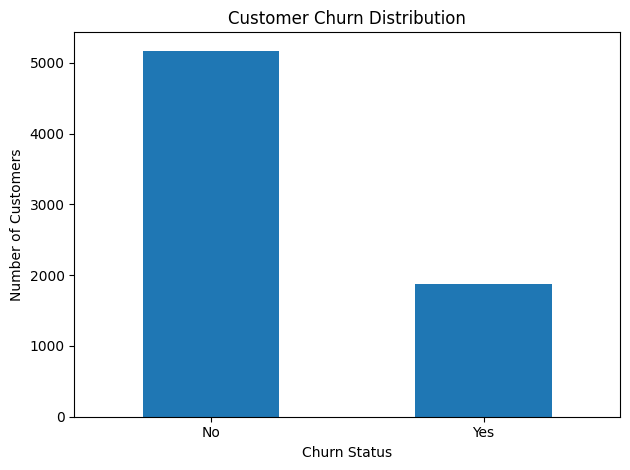

In [10]:
churn_summary = pd.DataFrame({
    "Count": df_clean["Churn"].value_counts(),
    "Percentage": (
        df_clean["Churn"].value_counts(normalize=True) * 100
    ).round(2)
})

display(churn_summary)

df_clean["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [11]:
# Convert Churn into a binary target
target_mapping = {
    "No": 0,
    "Yes": 1
}

y = df_clean["Churn"].map(target_mapping)

# Remove the target and unique identifier
X = df_clean.drop(
    columns=["Churn", "customerID"]
)

print("Predictor matrix shape:", X.shape)
print("Target vector shape:", y.shape)

print("\nTarget values:")
print(y.value_counts().sort_index())

print("\nTarget interpretation:")
print("0 = No churn")
print("1 = Churn")

# Validation
assert y.isna().sum() == 0
assert set(y.unique()) == {0, 1}
assert "customerID" not in X.columns
assert "Churn" not in X.columns

display(X.head())

Predictor matrix shape: (7043, 19)
Target vector shape: (7043,)

Target values:
Churn
0    5174
1    1869
Name: count, dtype: int64

Target interpretation:
0 = No churn
1 = Churn


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


In [12]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])

split_summary = pd.DataFrame({
    "Complete Dataset": (
        y.value_counts(normalize=True).sort_index() * 100
    ),
    "Training Set": (
        y_train.value_counts(normalize=True).sort_index() * 100
    ),
    "Testing Set": (
        y_test.value_counts(normalize=True).sort_index() * 100
    )
}).round(2)

split_summary.index = ["No Churn", "Churn"]

display(split_summary)

Training records: 5634
Testing records: 1409


,Complete Dataset,Training Set,Testing Set
No Churn,73.46,73.46,73.46
Churn,26.54,26.54,26.54


In [13]:
numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

print("\nNumber of numerical features:",
      len(numerical_features))

print("Number of categorical features:",
      len(categorical_features))

assert len(numerical_features) + len(categorical_features) == X.shape[1]

Numerical features:
['tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Number of numerical features: 3
Number of categorical features: 16


In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Compatibility across scikit-learn versions
try:
    one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )
except TypeError:
    one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )

numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            one_hot_encoder
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [16]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    make_scorer,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring_metrics = {
    "accuracy": make_scorer(accuracy_score),
    "precision": make_scorer(
        precision_score,
        zero_division=0
    ),
    "recall": make_scorer(
        recall_score,
        zero_division=0
    ),
    "f1": make_scorer(
        f1_score,
        zero_division=0
    ),
    "roc_auc": "roc_auc"
}


def evaluate_with_cross_validation(
    model_name,
    pipeline,
    features,
    target
):
    scores = cross_validate(
        pipeline,
        features,
        target,
        cv=cross_validation,
        scoring=scoring_metrics,
        n_jobs=-1,
        return_train_score=False
    )

    results = {
        "Model": model_name
    }

    for metric in scoring_metrics:
        values = scores[f"test_{metric}"]

        results[f"{metric.title()} Mean"] = np.mean(values)
        results[f"{metric.title()} SD"] = np.std(values)

    return results

In [17]:
from sklearn.dummy import DummyClassifier

baseline_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            DummyClassifier(
                strategy="most_frequent"
            )
        )
    ]
)

baseline_cv_results = evaluate_with_cross_validation(
    model_name="Dummy Classifier",
    pipeline=baseline_pipeline,
    features=X_train,
    target=y_train
)

baseline_table = pd.DataFrame(
    [baseline_cv_results]
)

display(baseline_table.round(4))

,Model,Accuracy Mean,Accuracy SD,Precision Mean,Precision SD,Recall Mean,Recall SD,F1 Mean,F1 SD,Roc_Auc Mean,Roc_Auc SD
0,Dummy Classifier,0.7346,0.0001,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0


In [18]:
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                random_state=RANDOM_STATE
            )
        )
    ]
)

logistic_cv_results = evaluate_with_cross_validation(
    model_name="Logistic Regression",
    pipeline=logistic_pipeline,
    features=X_train,
    target=y_train
)

comparison_table = pd.DataFrame([
    baseline_cv_results,
    logistic_cv_results
])

display(comparison_table.round(4))

,Model,Accuracy Mean,Accuracy SD,Precision Mean,Precision SD,Recall Mean,Recall SD,F1 Mean,F1 SD,Roc_Auc Mean,Roc_Auc SD
0,Dummy Classifier,0.7346,0.0001,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.5000,0.0000
1,Logistic Regression,0.8019,0.0118,0.6521,0.0256,0.5438,0.0409,0.5924,0.0298,0.8461,0.0126


,Model,Accuracy Mean,Precision Mean,Recall Mean,F1 Mean,Roc_Auc Mean
0,Dummy Classifier,0.7346,0.0000,0.0000,0.0000,0.5000
1,Logistic Regression,0.8019,0.6521,0.5438,0.5924,0.8461


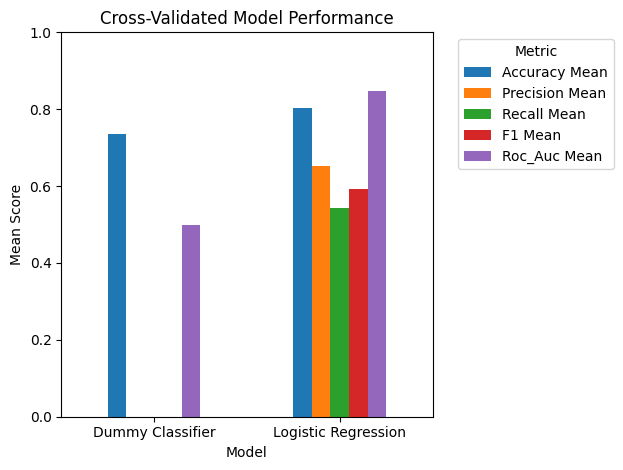

In [19]:
comparison_metrics = comparison_table[[
    "Model",
    "Accuracy Mean",
    "Precision Mean",
    "Recall Mean",
    "F1 Mean",
    "Roc_Auc Mean"
]].copy()

display(comparison_metrics.round(4))

comparison_metrics.set_index("Model").plot(
    kind="bar"
)

plt.title("Cross-Validated Model Performance")
plt.xlabel("Model")
plt.ylabel("Mean Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(
    title="Metric",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

In [20]:
def evaluate_model_with_overfitting_check(
    model_name,
    pipeline,
    features,
    target
):
    scores = cross_validate(
        pipeline,
        features,
        target,
        cv=cross_validation,
        scoring=scoring_metrics,
        n_jobs=-1,
        return_train_score=True
    )

    result = {
        "Model": model_name
    }

    for metric in scoring_metrics:
        metric_name = metric.replace("_", " ").title()

        train_scores = scores[f"train_{metric}"]
        validation_scores = scores[f"test_{metric}"]

        result[f"Train {metric_name}"] = train_scores.mean()
        result[f"CV {metric_name}"] = validation_scores.mean()
        result[f"CV {metric_name} SD"] = validation_scores.std()

    result["F1 Generalisation Gap"] = (
        result["Train F1"] -
        result["CV F1"]
    )

    result["ROC-AUC Generalisation Gap"] = (
        result["Train Roc Auc"] -
        result["CV Roc Auc"]
    )

    return result

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

model_definitions = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    )
}

model_pipelines = {}
model_results = []

for model_name, classifier in model_definitions.items():

    model_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", classifier)
        ]
    )

    model_pipelines[model_name] = model_pipeline

    print(f"Evaluating {model_name}...")

    result = evaluate_model_with_overfitting_check(
        model_name=model_name,
        pipeline=model_pipeline,
        features=X_train,
        target=y_train
    )

    model_results.append(result)

print("\nAll models evaluated successfully.")

Evaluating Logistic Regression...
Evaluating Decision Tree...
Evaluating Random Forest...
Evaluating Gradient Boosting...

All models evaluated successfully.


In [22]:
model_comparison = pd.DataFrame(model_results)

comparison_columns = [
    "Model",
    "CV Accuracy",
    "CV Precision",
    "CV Recall",
    "CV F1",
    "CV Roc Auc",
    "CV F1 SD",
    "Train F1",
    "F1 Generalisation Gap"
]

model_comparison_summary = (
    model_comparison[comparison_columns]
    .sort_values("CV F1", ascending=False)
    .reset_index(drop=True)
)

display(model_comparison_summary.round(4))

,Model,CV Accuracy,CV Precision,CV Recall,CV F1,CV Roc Auc,CV F1 SD,Train F1,F1 Generalisation Gap
0,Logistic Regression,0.8019,0.6521,0.5438,0.5924,0.8461,0.0298,0.6028,0.0103
1,Gradient Boosting,0.8035,0.6627,0.5291,0.5882,0.8482,0.0298,0.6468,0.0586
2,Random Forest,0.7867,0.6273,0.4856,0.5471,0.8202,0.0208,0.9968,0.4497
3,Decision Tree,0.7322,0.4957,0.5003,0.4975,0.6582,0.0140,0.9968,0.4993


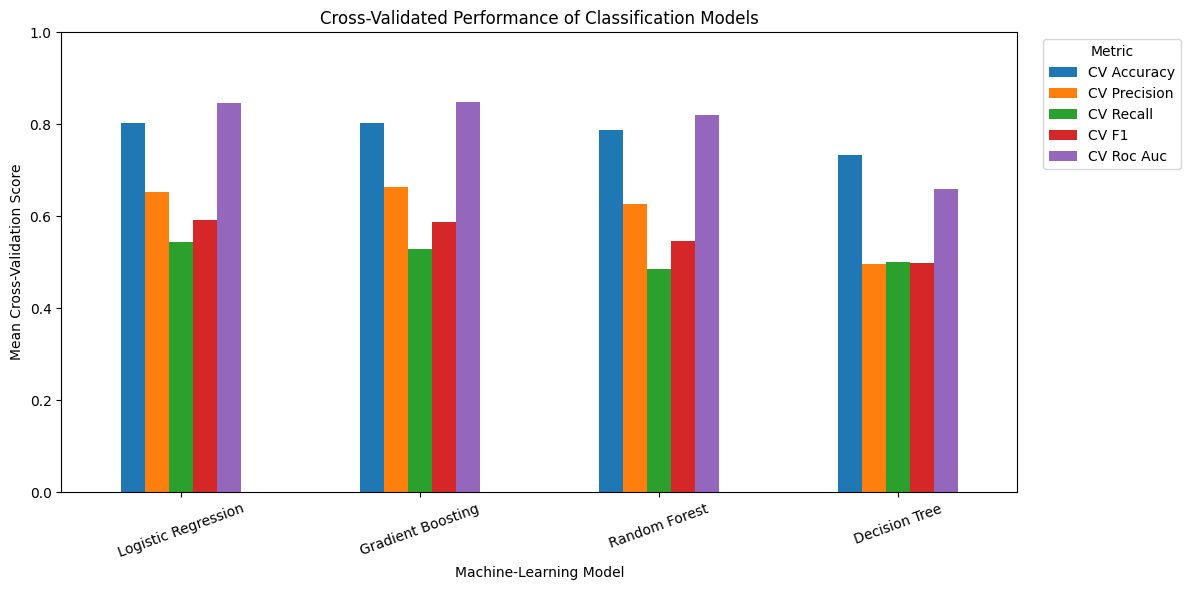

In [23]:
performance_plot = model_comparison_summary[
    [
        "Model",
        "CV Accuracy",
        "CV Precision",
        "CV Recall",
        "CV F1",
        "CV Roc Auc"
    ]
].set_index("Model")

performance_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Cross-Validated Performance of Classification Models")
plt.xlabel("Machine-Learning Model")
plt.ylabel("Mean Cross-Validation Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)

plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

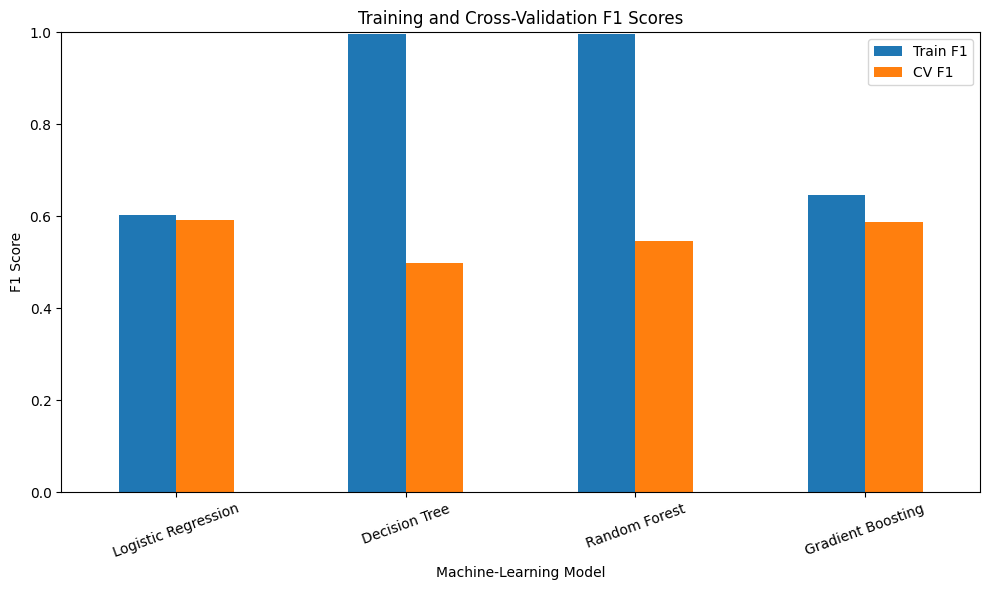

In [24]:
overfitting_plot = model_comparison[
    [
        "Model",
        "Train F1",
        "CV F1"
    ]
].set_index("Model")

overfitting_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Training and Cross-Validation F1 Scores")
plt.xlabel("Machine-Learning Model")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

final_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                random_state=RANDOM_STATE
            )
        )
    ]
)

final_model.fit(X_train, y_train)

print("Final Logistic Regression model trained successfully.")

Final Logistic Regression model trained successfully.


In [26]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

test_predictions = final_model.predict(X_test)
test_probabilities = final_model.predict_proba(X_test)[:, 1]

final_test_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Test Score": [
        accuracy_score(y_test, test_predictions),
        precision_score(
            y_test,
            test_predictions,
            zero_division=0
        ),
        recall_score(
            y_test,
            test_predictions,
            zero_division=0
        ),
        f1_score(
            y_test,
            test_predictions,
            zero_division=0
        ),
        roc_auc_score(
            y_test,
            test_probabilities
        )
    ]
})

display(final_test_results.round(4))

print("\nFinal Classification Report\n")

print(
    classification_report(
        y_test,
        test_predictions,
        target_names=[
            "No Churn",
            "Churn"
        ],
        zero_division=0
    )
)

,Metric,Test Score
0,Accuracy,0.8055
1,Precision,0.6572
2,Recall,0.5588
3,F1 Score,0.6040
4,ROC-AUC,0.8420



Final Classification Report

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



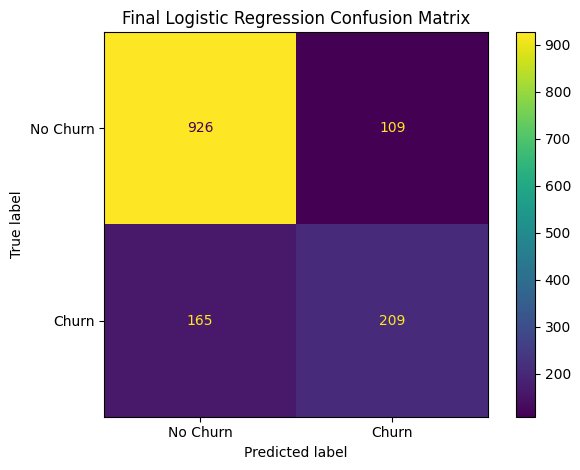

In [27]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    display_labels=[
        "No Churn",
        "Churn"
    ],
    values_format="d"
)

plt.title(
    "Final Logistic Regression Confusion Matrix"
)

plt.tight_layout()
plt.show()

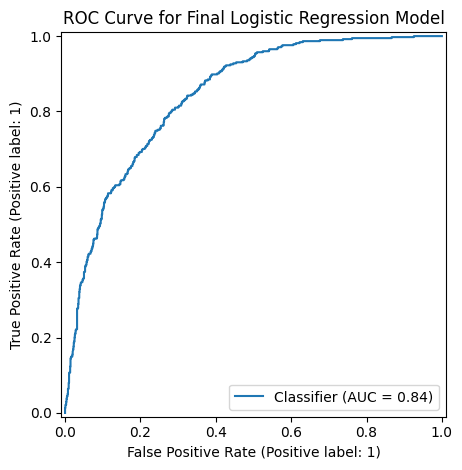

In [28]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    test_probabilities
)

plt.title(
    "ROC Curve for Final Logistic Regression Model"
)

plt.tight_layout()
plt.show()

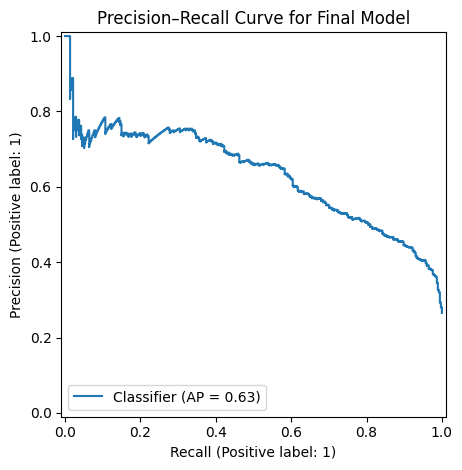

In [29]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(
    y_test,
    test_probabilities
)

plt.title(
    "Precision–Recall Curve for Final Model"
)

plt.tight_layout()
plt.show()

In [30]:
feature_names = (
    final_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients = (
    final_model
    .named_steps["classifier"]
    .coef_[0]
)

coefficient_table = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coefficient_table["Absolute Coefficient"] = (
    coefficient_table["Coefficient"].abs()
)

coefficient_table = (
    coefficient_table
    .sort_values(
        "Absolute Coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Most influential model features")

display(
    coefficient_table[
        ["Feature", "Coefficient"]
    ].head(15).round(4)
)

Most influential model features


,Feature,Coefficient
0,numerical__tenure,-1.2552
1,categorical__Contract_Two year,-0.7594
2,categorical__InternetService_Fiber optic,0.6480
3,categorical__InternetService_DSL,-0.6436
4,numerical__MonthlyCharges,-0.6012
5,categorical__Contract_Month-to-month,0.5860
6,numerical__TotalCharges,0.5326
7,categorical__PaperlessBilling_No,-0.3307
8,categorical__DeviceProtection_No internet service,-0.2930
9,categorical__OnlineSecurity_No internet service,-0.2930


In [31]:
import joblib

MODEL_FILENAME = "telco_churn_model.pkl"

joblib.dump(
    final_model,
    MODEL_FILENAME
)

print(
    f"Final model saved as {MODEL_FILENAME}"
)

Final model saved as telco_churn_model.pkl


In [32]:
import sklearn
import pandas as pd
import numpy as np
import joblib

requirements_content = f"""streamlit
pandas=={pd.__version__}
numpy=={np.__version__}
scikit-learn=={sklearn.__version__}
joblib=={joblib.__version__}
"""

with open(
    "requirements.txt",
    "w"
) as file:
    file.write(requirements_content)

print(requirements_content)

streamlit
pandas==2.2.2
numpy==2.0.2
scikit-learn==1.6.1
joblib==1.5.3



In [33]:
from google.colab import files

files.download(
    "telco_churn_model.pkl"
)

files.download(
    "requirements.txt"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>